In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
sns.set_style('whitegrid')
sns.set_palette("Set2")

%matplotlib inline

# Leer los datos

In [3]:
totales = pd.read_csv("../../data/respuestas_fede.csv")
print(totales.shape)

#globales
marmol = totales.loc[totales["escuela"] == "Colegio Modelo Mármol"]
mantovani = totales.loc[totales["escuela"] == "Escuela Nueva Juan Mantovani"]
cant_total = len(totales)
cant_marmol = len(marmol)
cant_mantovani = len(mantovani)
# genero
cant_marmol_masc = len(marmol[marmol['genero']=="Masculino"])
cant_marmol_fem = len(marmol[marmol['genero']=="Femenino"])
cant_mantovani_masc = len(mantovani[mantovani['genero']=="Masculino"])
cant_mantovani_fem = len(mantovani[mantovani['genero']=="Femenino"])
# grados
cant_marmol_quinto = len(marmol[marmol['grado']=="Quinto"])
cant_marmol_sexto = len(marmol[marmol['grado']=="Sexto"])
cant_mantovani_cuarto = len(mantovani[mantovani['grado']=="Cuarto"])
cant_mantovani_quinto = len(mantovani[mantovani['grado']=="Quinto"])
cant_mantovani_sexto = len(mantovani[mantovani['grado']=="Sexto"])
# nose que es la nube
nube_nose_totales   = totales    ["que_es_nube"].value_counts()["No sé"]
nube_nose_marmol    = marmol   ["que_es_nube"].value_counts()["No sé"]
nube_nose_mantovani = mantovani["que_es_nube"].value_counts()["No sé"]
# no se nube grados
nube_nose_marmol_quinto = marmol[marmol['grado']=="Quinto"]["que_es_nube"].value_counts()["No sé"]
nube_nose_marmol_sexto = marmol[marmol['grado']=="Sexto"]["que_es_nube"].value_counts()["No sé"]
nube_nose_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["que_es_nube"].value_counts()["No sé"]
nube_nose_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["que_es_nube"].value_counts()["No sé"]
nube_nose_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["que_es_nube"].value_counts()["No sé"]
# no se nube generos
nube_nose_marmol_masc    = marmol[marmol['genero']=="Masculino"]["que_es_nube"].value_counts()["No sé"]
nube_nose_marmol_fem     = marmol[marmol['genero']=="Femenino"]["que_es_nube"].value_counts()["No sé"]
nube_nose_mantovani_masc = mantovani[mantovani['genero']=="Masculino"]["que_es_nube"].value_counts()["No sé"]
nube_nose_mantovani_fem  = mantovani[mantovani['genero']=="Femenino"]["que_es_nube"].value_counts()["No sé"]
# no use wikipedia
wiki_no_totales          = totales    ["uso_wikipedia"].value_counts()["No"]
wiki_no_marmol           = marmol   ["uso_wikipedia"].value_counts()["No"]
wiki_no_mantovani        = mantovani["uso_wikipedia"].value_counts()["No"]
# no use wikipedia grados
wiki_no_marmol_quinto    = marmol[marmol['grado']=="Quinto"]["uso_wikipedia"].value_counts()["No"]
wiki_no_marmol_sexto     = marmol[marmol['grado']=="Sexto"]["uso_wikipedia"].value_counts()["No"]
wiki_no_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["uso_wikipedia"].value_counts()["No"]
wiki_no_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["uso_wikipedia"].value_counts()["No"]
wiki_no_mantovani_sexto  = mantovani[mantovani['grado']=="Sexto"]["uso_wikipedia"].value_counts()["No"]
# no use wikipedia genero
wiki_no_marmol_masc      = marmol[marmol['genero']=="Masculino"]["uso_wikipedia"].value_counts()["No"]
wiki_no_marmol_fem       = marmol[marmol['genero']=="Femenino"]["uso_wikipedia"].value_counts()["No"]
wiki_no_mantovani_masc   = mantovani[mantovani['genero']=="Masculino"]["uso_wikipedia"].value_counts()["No"]
wiki_no_mantovani_fem    = mantovani[mantovani['genero']=="Femenino"]["uso_wikipedia"].value_counts()["No"]

(369, 22)


## Qué es la nube vs Funcionalidad de la nube

In [35]:
# funcion aux para analizar misc
def analizarMiscFuncionalidad(val, agrupando = False):
    lista = val.split(",")
    misc = 0
    not_misc = 0
    if(lista == ["0"]): # Si no seleccionaron ninguna rta, es porque contestaron no se en la pregunta anterior
        return "Sin\nRta." 
    
    # respuestas sin misconception, # not_misc
    if "Lanubemepermiteguardarlasfotosyvideosdelcelular" in lista:
        not_misc = not_misc + 1
    if "InstagramyTikTokusanlanubeparacompartirsusvideos" in lista:
        not_misc = not_misc + 1
    if "Sepuedeusarlanubeparajugarjuegossininstalarlos" in lista:
        not_misc = not_misc + 1
    if "GoogleMapsdescargasusmapasdelanube" in lista:
        not_misc = not_misc + 1

    # respuestas con misconception, # misc
    if "PodemosutilizarlanubesinconexiónaInternet" in lista:
        misc = misc + 1
    if "Sinlanubeseríaimposibleescucharmúsicaenelcelular" in lista:
        misc = misc + 1
    if "Sinlanubenoseríaposiblehacerllamadasporcelular" in lista:
        misc = misc + 1
    if "Sinlanubeseríaimposiblesacarfotosconelcelular" in lista:
        misc = misc + 1
    
    if(not agrupando):
        if(not_misc == misc):
            return "Iguales\nMisc. y\nNo Misc."    
        if(misc == 0):
            return "Ninguna\nMisc."        
        if(not_misc == 0):
            return "Todas\nMisc."      
        if(not_misc > misc):        
            return "Minoría\nMisc."    
        if(misc > not_misc):
            return "Mayoría\nMisc."
    else:
        if(not_misc == misc):
            return "Iguales\nMisc. y\nNo Misc."      
        if(not_misc > misc):        
            return "Minoría\nMisc."    
        if(misc > not_misc):
            return "Mayoría\nMisc."

def analizarMiscNube(val):
    if val == "Una nube":
        return "Misc. fuerte"
    if val == "Una parte del celular":
        return "Misc. fuerte"
    if val == "Una computadora gigante":
        return "Misc. fuerte"
    if val == "Una red de antenas y satélites":
        return "Misc. débil"
    if val == "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)":
        return "Sin Misc."
    

In [42]:
# Boilerplate para generar este gráfico
def nube_vs_funcionalidad(df, df_name, agrupando = False):
    que_es_nube = df["que_es_nube"]
    que_es_nube_sin_nose = que_es_nube[que_es_nube != "No sé"]

    misconceptions_funcionalidad_nube = df["afirmaciones_nube"].str.replace(" ", "").fillna("0").apply(lambda x: analizarMiscFuncionalidad(x,agrupando))
    misconceptions_funcionalidad_nube_sin_sinrta = misconceptions_funcionalidad_nube[misconceptions_funcionalidad_nube != "Sin\nRta."]

    if(agrupando):
        filas = ["Sin Misc.",
                 "Misc. débil",
                 "Misc. fuerte"]
        columnas = ["Mayoría\nMisc.",
                    "Iguales\nMisc. y\nNo Misc.",
                    "Minoría\nMisc."]
        que_es_nube_sin_nose = que_es_nube_sin_nose.apply(analizarMiscNube)
        
    else:
        filas = ["Una nube",
                 "Una parte del celular",
                 "Una compu gigante", 
                 "Una red de antenas y satélites",
                 "Muchísimas compus"]
        columnas = ["Todas\nMisc.",
                    "Mayoría\nMisc.",
                    "Iguales\nMisc. y\nNo Misc.",
                    "Minoría\nMisc.",
                    "Ninguna\nMisc."]

    cross_tab_result = pd.crosstab(que_es_nube_sin_nose, misconceptions_funcionalidad_nube_sin_sinrta)

    totalsum = cross_tab_result.sum().sum()

    cross_tab_result = cross_tab_result.div(totalsum)

    cross_tab_result = cross_tab_result.rename(index={"Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas compus",
                                "Una computadora gigante":"Una compu gigante"})

    # ordenamos de misconception más fuerte a más debil en las filas y de mayor misconception a menor en filas
    cross_tab_result = cross_tab_result.reindex(filas, columns=columnas)


    sns.heatmap(cross_tab_result, cmap='YlGnBu', annot=True, fmt='.2f', linewidths=0.5)
    plt.title('Relación de Respuestas\nQue es la nube vs Funcionalidad de la nube\nDatos {} - Agrupando {}'.format(df_name,agrupando))
    plt.xlabel('Misconceptions Funcionalidad Nube')
    plt.ylabel('Que es la nube')
    plt.show()
    plt.savefig('rel_nube_vs_func_{}_agrupando_{}.png'.format(df_name,agrupando))
    plt.clf()

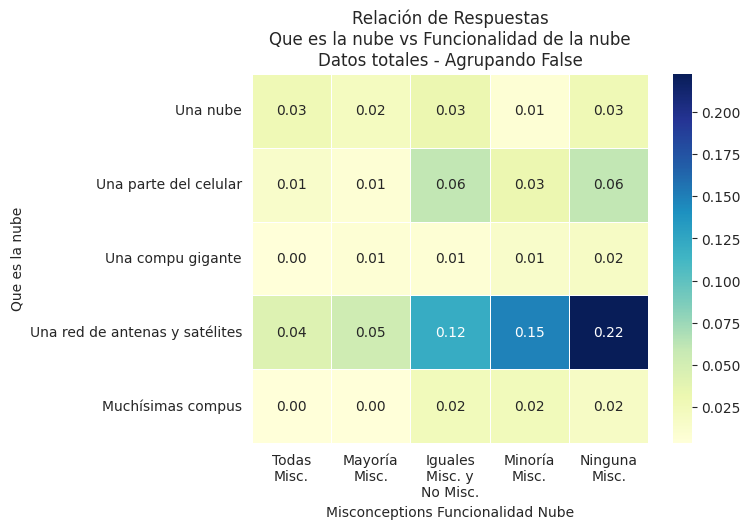

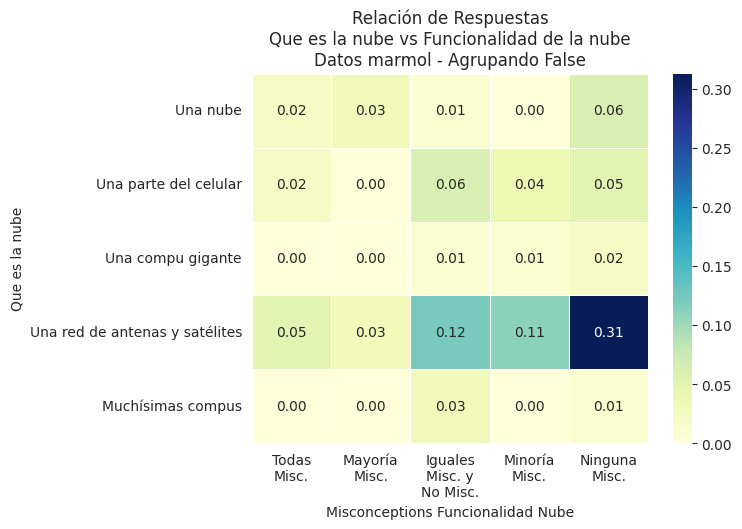

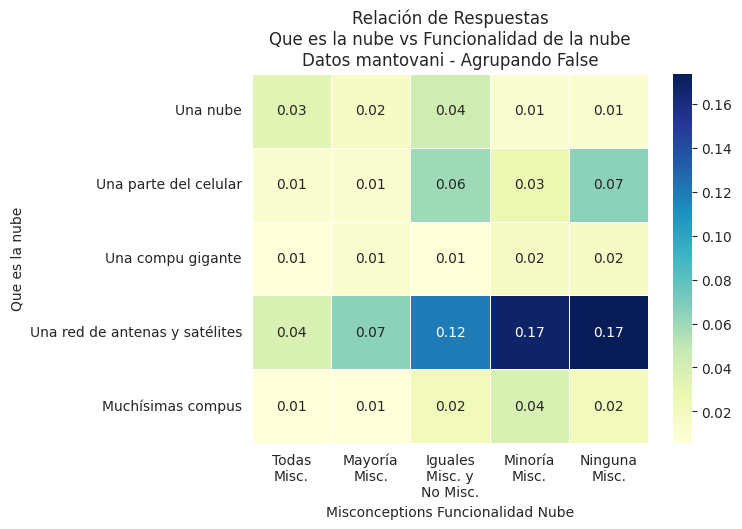

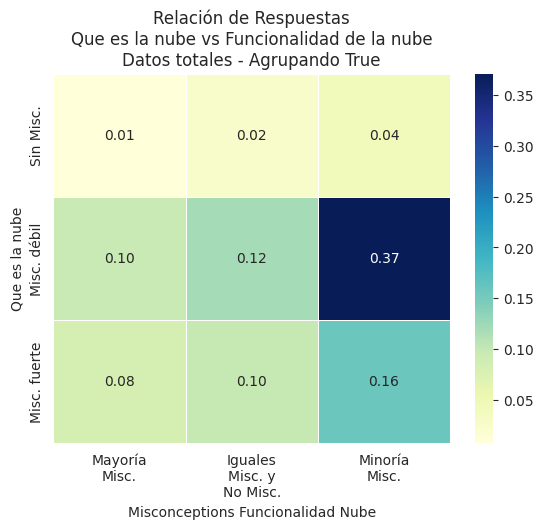

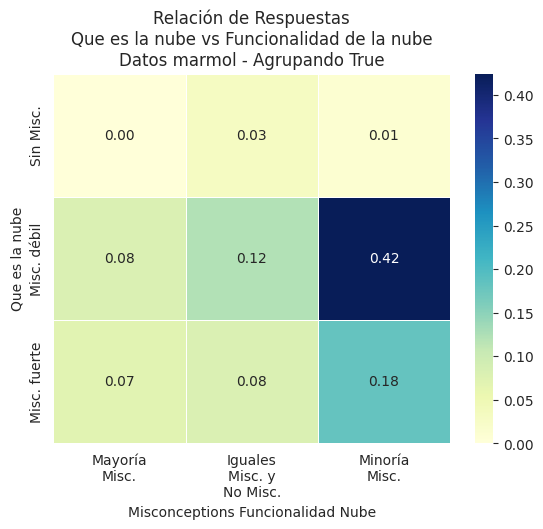

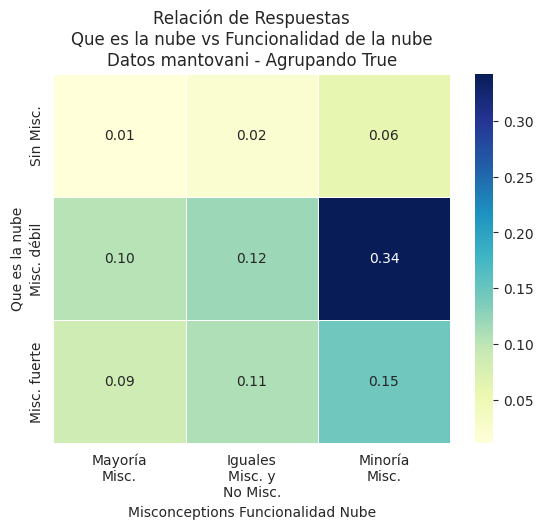

<Figure size 640x480 with 0 Axes>

In [43]:
# llamo al generador de graficos con los tres dfs
nube_vs_funcionalidad(totales, "totales")
nube_vs_funcionalidad(marmol, "marmol")
nube_vs_funcionalidad(mantovani, "mantovani")

# Agrupando misc
nube_vs_funcionalidad(totales, "totales", True)
nube_vs_funcionalidad(marmol, "marmol", True)
nube_vs_funcionalidad(mantovani, "mantovani", True)

## Link de wpp vs Funcionalidad de Wikipedia

## Qué puedo hacer para q no vea la foto vs Son copia o referencia